In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split

In [ ]:
path_to_test = "data/original_data/data/customer_clv_test.csv"
path_to_train = "data/original_data/data/customer_clv_train.csv"
path_to_transactions = "data/original_data/data/transactions_2016_2017.csv"

In [5]:
path_to_test = r"C:\Users\Marte\Documents\SCHOOL\2024_2026_KUL\2025-2026\SEMESTER 2\Advanced Analytics in a Big Data World\Assignment1\data\data\customer_clv_test.csv"
path_to_train = r"C:\Users\Marte\Documents\SCHOOL\2024_2026_KUL\2025-2026\SEMESTER 2\Advanced Analytics in a Big Data World\Assignment1\data\data\customer_clv_train.csv"
path_to_transactions = r"C:\Users\Marte\Documents\SCHOOL\2024_2026_KUL\2025-2026\SEMESTER 2\Advanced Analytics in a Big Data World\Assignment1\data\data\transactions_2016_2017.csv"

In [6]:
train = pd.read_csv(path_to_train)
test = pd.read_csv(path_to_test)
transactions = pd.read_csv(path_to_transactions)

print("Dimensions: train:", train.shape, " test:", test.shape, 'transactions:', transactions.shape)
print("Train columns:", train.columns.to_list())
print("Transaction columns:", transactions.columns.to_list())

C:\Users\Marte\AppData\Local\Temp\ipykernel_17904\3911849424.py:3: DtypeWarning: Columns (0: prod_size) have mixed types. Specify dtype option on import or set low_memory=False.
  transactions = pd.read_csv(path_to_transactions)


Dimensions: train: (116591, 2)  test: (29148, 1) transactions: (344212, 26)
Train columns: ['cust_id', 'revenue_2018_2019']
Transaction columns: ['cust_id', 'order_date', 'pack_date', 'sale_id', 'sale_discount_applied', 'sale_revenue', 'returned_to_shop_id', 'prod_id', 'prod_size', 'prod_web_only', 'prod_season', 'prod_brand', 'prod_title', 'prod_color', 'prod_type_1', 'prod_type_3', 'prod_type_4', 'prod_type_5', 'prod_heel', 'prod_material', 'prod_insole', 'prod_print', 'prod_comfort_sole', 'prod_comfort_wear', 'prod_clasp', 'prod_outlet']


In [7]:
train.head()

,cust_id,revenue_2018_2019
0,klantwj2374mzmab,209.85
1,a63atwr2ig2jfprr,82.93
2,zr7ihbfbi6gcy2tz,89.95
3,dt7cthjqnjmkbiu6,0.00
4,etcrrgcbrzfovyzj,0.00


In [8]:
transactions.head()

,cust_id,order_date,pack_date,sale_id,sale_discount_applied,sale_revenue,returned_to_shop_id,prod_id,prod_size,prod_web_only,...,prod_type_4,prod_type_5,prod_heel,prod_material,prod_insole,prod_print,prod_comfort_sole,prod_comfort_wear,prod_clasp,prod_outlet
0,klantwj2374mzmab,2016-01-01,2016-01-04,wa46phiwo6neterg,-35.70,83.30,NaN,543rj4mzzjnzkbil,30.0,0,...,NaN,boots (velcro),NaN,leather,1.0,NaN,NaN,NaN,velcro,0
1,klantwj2374mzmab,2016-01-01,2016-01-04,wa46phiwo6neterg,-39.98,0.00,ztodvuuaje,7ewnqhtrquent4cy,44.0,0,...,NaN,dress boots,NaN,leather,0.0,NaN,NaN,NaN,zipper,0
2,a63atwr2ig2jfprr,2016-01-01,2016-01-04,p4y4726y24dcxawf,-24.00,0.00,5tiaacoboa,cwtye5jwqr43a56i,38.5,0,...,high-top sneakers,lace-up shoes,NaN,suede,NaN,NaN,NaN,NaN,NaN,0
3,zr7ihbfbi6gcy2tz,2016-01-01,2016-01-05,3etkl2xv6pxku4kt,-26.23,43.72,NaN,mqw2seipp2wtylnw,35.0,0,...,NaN,velcro shoes,NaN,synthetic leather,0.0,NaN,NaN,breathable,velcro,0
4,dt7cthjqnjmkbiu6,2016-01-01,2016-01-05,lneitdgyfvrie3jo,-29.98,0.00,geja5b25na,5ut47kvr6zlx6y62,25.0,0,...,NaN,boots (velcro),NaN,NaN,NaN,NaN,NaN,NaN,velcro,0


In [9]:
transactions["order_date"] = pd.to_datetime(transactions["order_date"], errors='coerce')
transactions['pack_date'] = pd.to_datetime(transactions["pack_date"], errors='coerce')

print("missing values in order_date:", transactions["order_date"].isna().sum())
print("missing values in pack_date:", transactions['pack_date'].isna().sum())

missing values in order_date: 0
missing values in pack_date: 0


rows : 116591 | percent of O: 63.41
count    116591.000000
mean         70.364667
std         144.303602
min           0.000000
50%           0.000000
90%         229.940000
95%         363.465000
99%         704.242000
max        1197.940000
Name: revenue_2018_2019, dtype: float64


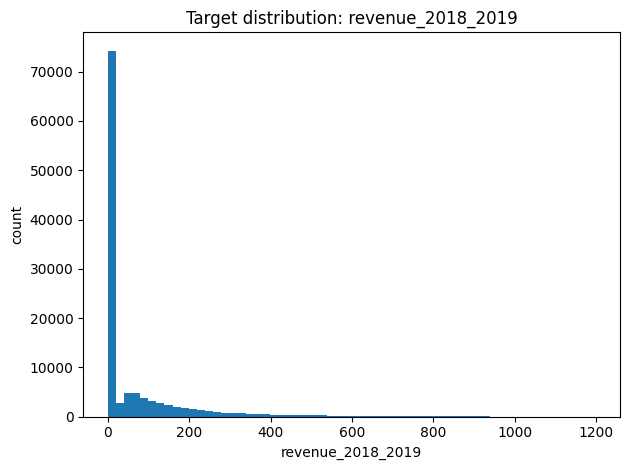

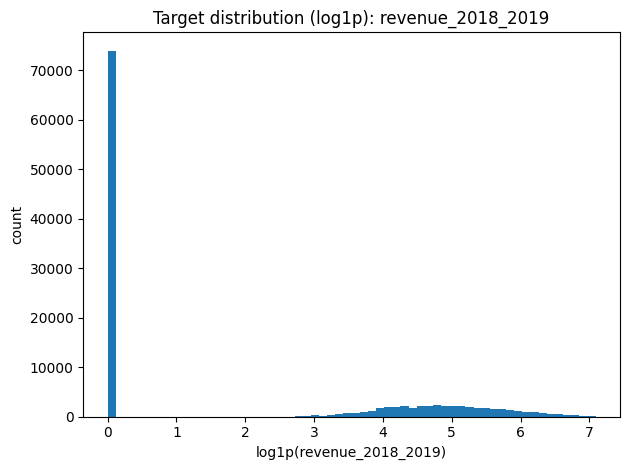

In [10]:
TARGET_VAR = "revenue_2018_2019"

y = pd.to_numeric(train[TARGET_VAR].dropna())
print('rows :', len(y), "| percent of O:", round(y.eq(0).mean() * 100,2))
print(y.describe(percentiles=[.5,.9,.95,.99]))

plt.figure()
plt.hist(y, bins=60)
plt.title(f"Target distribution: {TARGET_VAR}")
plt.xlabel(TARGET_VAR); plt.ylabel("count")
plt.tight_layout(); plt.show()

plt.figure()
plt.hist(np.log1p(y), bins=60)
plt.title(f"Target distribution (log1p): {TARGET_VAR}")
plt.xlabel(f"log1p({TARGET_VAR})"); plt.ylabel("count")
plt.tight_layout(); plt.show()



In [11]:
print(np.log1p(y).describe(percentiles=[.5,.9,.95,.99]))

count    116591.000000
mean          1.793202
std           2.416395
min           0.000000
50%           0.000000
90%           5.442158
95%           5.898431
99%           6.558541
max           7.089193
Name: revenue_2018_2019, dtype: float64


In [12]:
print(len(transactions['prod_brand'].unique()))

493


In [13]:
for column in transactions.columns.tolist():
    print("Missing values in", column, 'is', transactions[column].isna().sum(), " and percentage of the column missing", round(transactions[column].isna().mean() * 100, 2))

Missing values in cust_id is 0  and percentage of the column missing 0.0
Missing values in order_date is 0  and percentage of the column missing 0.0
Missing values in pack_date is 0  and percentage of the column missing 0.0
Missing values in sale_id is 0  and percentage of the column missing 0.0
Missing values in sale_discount_applied is 0  and percentage of the column missing 0.0
Missing values in sale_revenue is 0  and percentage of the column missing 0.0
Missing values in returned_to_shop_id is 280282  and percentage of the column missing 81.43
Missing values in prod_id is 0  and percentage of the column missing 0.0
Missing values in prod_size is 0  and percentage of the column missing 0.0
Missing values in prod_web_only is 0  and percentage of the column missing 0.0
Missing values in prod_season is 0  and percentage of the column missing 0.0
Missing values in prod_brand is 0  and percentage of the column missing 0.0
Missing values in prod_title is 0  and percentage of the column mi

In [14]:
for column in transactions.columns.to_list():
    print('Descriptive statistics for', column, ':', transactions[column].describe())

Descriptive statistics for cust_id : count               344212
unique              145739
top       yvmh4jb3ltqygxnt
freq                   142
Name: cust_id, dtype: object
Descriptive statistics for order_date : count                        344212
mean     2017-01-21 04:59:20.884571
min             2016-01-01 00:00:00
25%             2016-07-26 00:00:00
50%             2017-01-30 00:00:00
75%             2017-07-14 06:00:00
max             2017-12-31 00:00:00
Name: order_date, dtype: object
Descriptive statistics for pack_date : count                        344212
mean     2017-01-22 20:23:55.682661
min             2016-01-03 00:00:00
25%             2016-07-27 00:00:00
50%             2017-02-02 00:00:00
75%             2017-07-17 00:00:00
max             2018-01-12 00:00:00
Name: pack_date, dtype: object
Descriptive statistics for sale_id : count               344212
unique              245928
top       lwvlicnwtljqoq7z
freq                    28
Name: sale_id, dtype: object
Descri

In [15]:
for column in ["prod_clasp","prod_comfort_wear","prod_comfort_sole","prod_print","prod_insole","prod_heel","prod_type_4"]:
    transactions.drop(column, axis=1, inplace=True)

In [16]:
## for returned_to_shop_id , prod_type_5 , prod_material NANs ???
for column in ["prod_type_5","prod_material","returned_to_shop_id"]:
    transactions[column].fillna('missing', inplace=True)

## still relevant to keep this feature with so many NaNs ??

C:\Users\Marte\AppData\Local\Temp\ipykernel_17904\1170069323.py:3: ChainedAssignmentError: A value is being set on a copy of a DataFrame or Series through chained assignment using an inplace method.
Such inplace method never works to update the original DataFrame or Series, because the intermediate object on which we are setting values always behaves as a copy (due to Copy-on-Write).

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' instead, to perform the operation inplace on the original object, or try to avoid an inplace operation using 'df[col] = df[col].method(value)'.

See the documentation for a more detailed explanation: https://pandas.pydata.org/pandas-docs/stable/user_guide/copy_on_write.html
  transactions[column].fillna('missing', inplace=True)


In [17]:
## duplicates
count= transactions.duplicated().sum()
percentage= round(count/len(transactions)*100,2)
print("Duplicated rows:",count, "percentage:", percentage )
## <1% so no problem

Duplicated rows: 1063 percentage: 0.31


In [18]:
for column in ["prod_season","prod_color","prod_type_1","prod_type_3","prod_type_5","prod_material"]:
    print("Unique for" ,column, sorted(transactions[column].unique()))

Unique for prod_season ['CONS', 'MW14', 'MW17', 'MZ15', 'MZ16', 'MZ17', 'NOS', 'SW17', 'SZ17', 'SZ18', 'W12', 'W13', 'W14', 'W15', 'W16', 'W17', 'W18', 'Z13', 'Z14', 'Z15', 'Z16', 'Z17', 'Z18']
Unique for prod_color ['aubergine', 'black', 'blue', 'bronze', 'brown', 'burgundy', 'camouflage', 'cognac', 'dark beige', 'dark blue', 'dark brown', 'dark green', 'dark grey', 'dark red', 'dark yellow', 'ecru', 'fuchsia', 'gold', 'green', 'grey', 'khaki', 'light beige', 'light blue', 'light brown', 'light green', 'light grey', 'light red', 'light yellow', 'multicolored', 'natural', 'olive green', 'orange', 'pearl', 'pink', 'purple', 'red', 'silver', 'taupe', 'turquoise', 'white', 'yellow']
Unique for prod_type_1 ['boys', 'girls', 'men', 'women']
Unique for prod_type_3 ['ankle boots', 'ankle boots, boots', 'ankle boots, low shoes', 'ankle boots, pumps', 'ankle boots, sneakers', 'ankle boots, snow boots', 'baby shoes', 'ballet flats', 'ballet flats, low shoes', 'boots', 'boots, ankle boots', 'boot

TypeError: '<' not supported between instances of 'float' and 'str'

In [19]:
print("Unique prod_brand:" , sorted(transactions["prod_brand"].unique()))

Unique prod_brand: ['0051', 'Acebos', 'Aeros', 'Aerosoles', 'Aigle', 'Alberola', 'Alma en Pena', 'Aloha', 'Altramarea', 'Altraofficina', 'Ambiorix', 'Andrea Morelli', 'Angie', 'Angry Birds', 'Ani', 'Ania', 'Anna Dé Valle', 'Anna Lenci', 'Antibes', 'Apple Love', 'Apple of Eden', 'Apples & Pears', 'Ara', 'Armistice', 'Art', 'Art Star', 'Artigiano Italiano', 'Asics', 'Asso', 'Australian', 'BK', 'Bana', 'Bana & Co', 'Be Natural', 'Be Only', 'Beberlis', 'Bedroom Athletics', 'Belizia', 'Bellamy', 'Bellissima', 'Bensimon', 'Berghen', 'Bergstein', 'Bertuchi', 'Betula', 'Beyblade', 'Bibi Lou', 'Bibob', 'Big Leaf', 'Bijoux', 'Bio Dream', 'Biomodex', 'Birkenstock', 'Bisgaard', 'Bits & Bytes', 'Björn Borg', 'Blackstone', 'Blink', 'Blue Haven', 'Blundstone', 'Bonneville', 'Bopy', 'Borgo Sport', 'Bprivate', 'Brako', 'Brako Anatomics', 'Brax', 'Bronx', 'Bruno Premi', 'Buffalo', 'Bugatti', 'Bullboxer', 'Bumba', 'CA4LA', 'CKS', 'CMP', 'CR7', 'Cafeina', 'Cafènoir', 'Cal', 'Calvin Klein', 'Calzamur', 'Ca

In [20]:
transactions["prod_brand"]=transactions['prod_brand'].replace('Bana & Co', 'Bana')
transactions["prod_brand"]=transactions['prod_brand'].replace('Brako Anatomics', 'Brako')
transactions["prod_brand"]=transactions['prod_brand'].replace('Gabor Kids', 'Gabor')
transactions["prod_brand"]=transactions['prod_brand'].replace('Ragazzi Sport', 'Ragazzi')

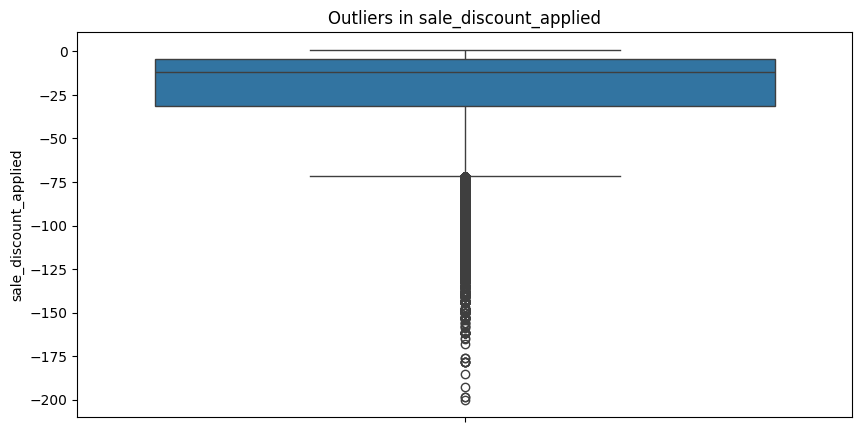

number of outliers: 12775 , percentage: 3.71


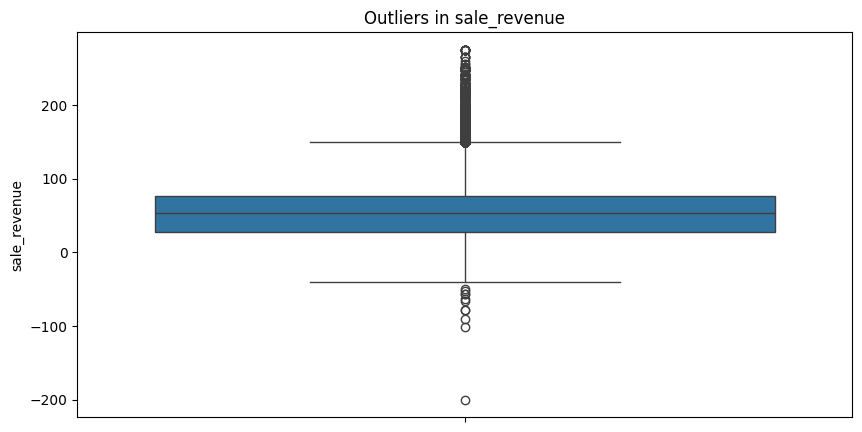

number of outliers: 5003 , percentage: 1.45


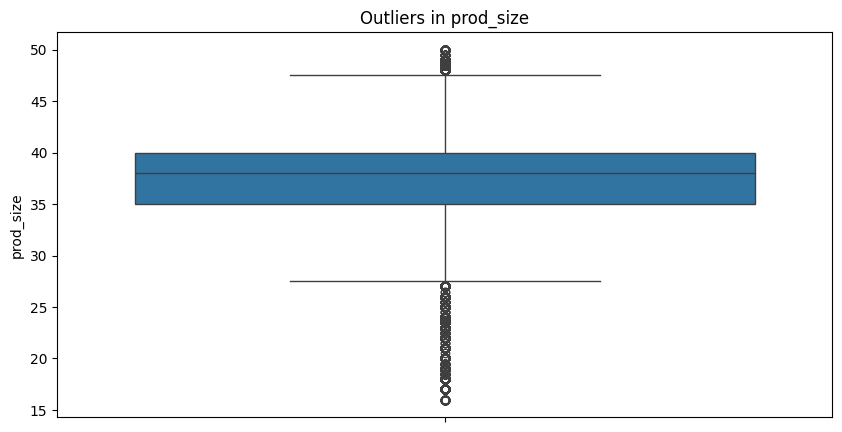

number of outliers: 36712 , percentage: 10.67


In [21]:
for column in ["sale_discount_applied", "sale_revenue", "prod_size"]:

    transactions[column]= pd.to_numeric(transactions[column],errors='coerce')
    transactions[column].dropna()
    
    plt.figure(figsize=(10, 5))
    sns.boxplot(y=transactions[column])
    plt.title(f'Outliers in {column}')
    plt.show()


    Q1=transactions[column].quantile(0.25)
    Q3=transactions[column].quantile(0.75)
    IQR= Q3-Q1
    count= ((transactions[column]<Q1-1.5*IQR) | (transactions[column]>Q3+1.5*IQR)).sum()
    percentage= round(count/len(transactions) *100 ,2)
    print("number of outliers:",count, ", percentage:", percentage)

In [22]:
transactions['prod_size_bin'] = pd.cut(transactions['prod_size'], bins=[0, 35, 44, 100], labels=[1, 2, 3]) #1=kids, 2=standard, 3=big size
print(transactions['prod_size_bin'].value_counts())

prod_size_bin
2    242602
1     87186
3     14423
Name: count, dtype: int64


In [23]:
print((transactions["sale_revenue"]<0).sum())

print((transactions[transactions["sale_revenue"]<0]).head())

2726
              cust_id order_date  pack_date           sale_id  \
160  drfh2oherb7najov 2016-01-01 2016-01-04  il53x7ywpcfjshtl   
222  6wkol4xmhbjwyqpk 2016-01-01 2016-01-05  yfuvxqckd3kdfqoj   
223  zsch7wkpbwgtjktd 2016-01-01 2016-01-04  4jdj25dp43g5bizd   
293  6o7ycr4ybvsxoy77 2016-01-02 2016-01-04  mlcqkvk4tpfwfpiz   
355  pfw3tsdwgbwtd723 2016-01-02 2016-01-04  dx2r47hus35zovfv   

     sale_discount_applied  sale_revenue returned_to_shop_id  \
160                 -40.98         -5.00          wgvwpxz354   
222                 -33.00         -1.50          m4u2pedciy   
223                 -30.76         -5.88          tda6fq6yzi   
293                 -19.07         -3.08          ncfk3d5hru   
355                 -25.38         -1.40          wqnkwa54pu   

              prod_id  prod_size  prod_web_only prod_season prod_brand  \
160  keljrif27g6dkumn       41.0              1         W15     Replay   
222  xm4nita6sd6timfy       26.0              0         W15  Romagnoli 

In [24]:
transactions['discount_quantile'] = pd.qcut(transactions['sale_discount_applied'], q=5, labels=['Q1 (0-20%)', 'Q2 (20-40%)', 'Q3 (40-60%)', 'Q4 (60-80%)', 'Q5 (80-100%)'])
## Q1 = small discount, Q5= huge discount

transactions['revenue_quantile'] = pd.qcut(transactions['sale_revenue'], q=5,labels=['Q1 (0-20%)', 'Q2 (20-40%)', 'Q3 (40-60%)', 'Q4 (60-80%)', 'Q5 (80-100%)'])
## Q1 = small revenue, Q5= huge revenue


In [25]:
transactions.head()

,cust_id,order_date,pack_date,sale_id,sale_discount_applied,sale_revenue,returned_to_shop_id,prod_id,prod_size,prod_web_only,...,prod_title,prod_color,prod_type_1,prod_type_3,prod_type_5,prod_material,prod_outlet,prod_size_bin,discount_quantile,revenue_quantile
0,klantwj2374mzmab,2016-01-01,2016-01-04,wa46phiwo6neterg,-35.70,83.30,NaN,543rj4mzzjnzkbil,30.0,0,...,Bruine Velcrobottine STONES and BONES,dark brown,boys,high shoes,boots (velcro),leather,0,1,Q2 (20-40%),Q5 (80-100%)
1,klantwj2374mzmab,2016-01-01,2016-01-04,wa46phiwo6neterg,-39.98,0.00,ztodvuuaje,7ewnqhtrquent4cy,44.0,0,...,Mario Rossi Cognac Boot,cognac,men,high shoes,dress boots,leather,0,2,Q1 (0-20%),Q1 (0-20%)
2,a63atwr2ig2jfprr,2016-01-01,2016-01-04,p4y4726y24dcxawf,-24.00,0.00,5tiaacoboa,cwtye5jwqr43a56i,38.5,0,...,Gabor Blauwe Veterschoen met Dierenprint,blue,women,sneakers,lace-up shoes,suede,0,2,Q2 (20-40%),Q1 (0-20%)
3,zr7ihbfbi6gcy2tz,2016-01-01,2016-01-05,3etkl2xv6pxku4kt,-26.23,43.72,NaN,mqw2seipp2wtylnw,35.0,0,...,Geox Blauwe Velcroschoen,dark blue,boys,low shoes,velcro shoes,synthetic leather,0,1,Q2 (20-40%),Q3 (40-60%)
4,dt7cthjqnjmkbiu6,2016-01-01,2016-01-05,lneitdgyfvrie3jo,-29.98,0.00,geja5b25na,5ut47kvr6zlx6y62,25.0,0,...,STONES and BONES Taupe Velcroboots,taupe,boys,high shoes,boots (velcro),NaN,0,1,Q2 (20-40%),Q1 (0-20%)


In [26]:
train.head()

,cust_id,revenue_2018_2019
0,klantwj2374mzmab,209.85
1,a63atwr2ig2jfprr,82.93
2,zr7ihbfbi6gcy2tz,89.95
3,dt7cthjqnjmkbiu6,0.00
4,etcrrgcbrzfovyzj,0.00


In [27]:
#DORIAN
## Construction of the train dataset before splitting it.
df = transactions.merge(train, on="cust_id", how="inner")

print(df.shape)
df.head()

(275166, 23)


,cust_id,order_date,pack_date,sale_id,sale_discount_applied,sale_revenue,returned_to_shop_id,prod_id,prod_size,prod_web_only,...,prod_color,prod_type_1,prod_type_3,prod_type_5,prod_material,prod_outlet,prod_size_bin,discount_quantile,revenue_quantile,revenue_2018_2019
0,klantwj2374mzmab,2016-01-01,2016-01-04,wa46phiwo6neterg,-35.70,83.30,NaN,543rj4mzzjnzkbil,30.0,0,...,dark brown,boys,high shoes,boots (velcro),leather,0,1,Q2 (20-40%),Q5 (80-100%),209.85
1,klantwj2374mzmab,2016-01-01,2016-01-04,wa46phiwo6neterg,-39.98,0.00,ztodvuuaje,7ewnqhtrquent4cy,44.0,0,...,cognac,men,high shoes,dress boots,leather,0,2,Q1 (0-20%),Q1 (0-20%),209.85
2,a63atwr2ig2jfprr,2016-01-01,2016-01-04,p4y4726y24dcxawf,-24.00,0.00,5tiaacoboa,cwtye5jwqr43a56i,38.5,0,...,blue,women,sneakers,lace-up shoes,suede,0,2,Q2 (20-40%),Q1 (0-20%),82.93
3,zr7ihbfbi6gcy2tz,2016-01-01,2016-01-05,3etkl2xv6pxku4kt,-26.23,43.72,NaN,mqw2seipp2wtylnw,35.0,0,...,dark blue,boys,low shoes,velcro shoes,synthetic leather,0,1,Q2 (20-40%),Q3 (40-60%),89.95
4,dt7cthjqnjmkbiu6,2016-01-01,2016-01-05,lneitdgyfvrie3jo,-29.98,0.00,geja5b25na,5ut47kvr6zlx6y62,25.0,0,...,taupe,boys,high shoes,boots (velcro),NaN,0,1,Q2 (20-40%),Q1 (0-20%),0.00


In [28]:
customers = train["cust_id"]
y_binary = (train["revenue_2018_2019"] > 0).astype(int)

cust_cal, cust_val = train_test_split(
    customers,
    test_size=0.2,
    random_state=42,
    stratify=y_binary
)
X_cal = df[df["cust_id"].isin(cust_cal)]
X_val = df[df["cust_id"].isin(cust_val)]

Splitting on customer ID > advantages: no data leakages as the model doesn't see the same customer in the train and test data, good for new-customer prediction (and easy stratification), a little bit more difficult to predict future sales of the same customer (do not know if that's needed)

In [29]:
#Quick sanitity ceck
set(X_cal["cust_id"]).intersection(set(X_val["cust_id"]))
print("Original zero rate:", (train["revenue_2018_2019"] == 0).mean())

print(
    "Calibration zero rate:",
    X_cal.groupby("cust_id")["revenue_2018_2019"].first().eq(0).mean()
)

print(
    "Validation zero rate:",
    X_val.groupby("cust_id")["revenue_2018_2019"].first().eq(0).mean()
)

Original zero rate: 0.6341227024384386
Calibration zero rate: 0.6341238528175658
Validation zero rate: 0.6341181011192589


In [30]:
X_cal.to_csv("data/calibration_transactions.csv", index=False)
X_val.to_csv("data/validation_transactions.csv", index=False)
#Run this to create those dataset and instead of just having them in your kernel.